In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
logs_dir = Path("../experiments/agent/option_2_no_prioritized/logs/")

csv_files = sorted(logs_dir.glob("metrics_ep*.csv"))
csv_files

[WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_10_opt_step_0_916.csv'),
 WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_20_opt_step_916_1845.csv'),
 WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_30_opt_step_1845_2742.csv'),
 WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_40_opt_step_2742_3811.csv'),
 WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_50_opt_step_3811_4867.csv'),
 WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_60_opt_step_4867_5665.csv'),
 WindowsPath('../experiments/agent/option_2_no_prioritized/logs/metrics_ep_70_opt_step_5665_6594.csv')]

In [3]:
dataframes = [pd.read_csv(file) for file in csv_files]

logs = pd.concat(dataframes, ignore_index=True)

In [11]:
logs.head()

,optimization_step,global_step,episode,total_reward,total_loss,td_loss,kl_loss,total_dnd_inserts,total_dnd_updates
0,0,3911,1,4.756272,1.149863,1.149863,2.739881,533,0
1,1,3911,1,4.756272,0.783957,0.783957,2.765582,533,0
2,2,3911,1,4.756272,0.608402,0.608402,2.958289,533,0
3,3,3911,1,4.756272,0.922659,0.922659,3.071008,533,0
4,4,3911,1,4.756272,0.658783,0.658783,3.274541,533,0


In [4]:
td_error = np.sqrt(logs['td_loss'])
perc_5_75 = np.percentile(td_error, 100 - 5.7)
perc_5_75

np.float64(0.40139373052832017)

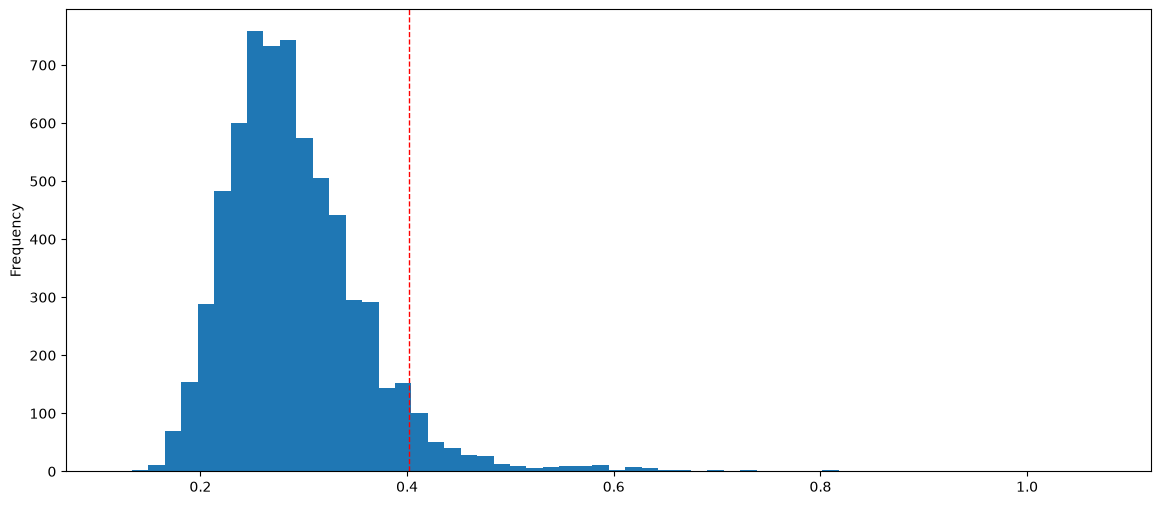

In [5]:
plt.figure(figsize=(14, 6))
td_error.plot(kind='hist', bins=60)
plt.axvline(perc_5_75, color='r', linestyle='dashed', linewidth=1, label=f'5.7% Percentile: {perc_5_75:.4f}')   
plt.show()

In [6]:
td_error_edited = td_error + 1

Numbers between 0 and 1 shrinks while we get their power with numbers that greater than 1. To prevent this logical bug, we add 1 to TD errors then calculate priorities.

In [41]:
td_error_edited

0       2.072316
1       1.885413
2       1.780002
3       1.960551
4       1.811654
          ...   
6589    1.272424
6590    1.253757
6591    1.260891
6592    1.265622
6593    1.277691
Name: td_loss, Length: 6594, dtype: float64

In [11]:
def compute_priority_probability(td_error_edited, perc, alpha):
    p = np.sum(np.power(td_error_edited[td_error_edited > (perc+1)], alpha)) / np.sum(np.power(td_error_edited, alpha))
    return p

In [12]:
compute_priority_probability(td_error_edited, perc_5_75, 7.07)

np.float64(0.15032975939540677)

According to experiment **``option_2_no_prioritized``** configurations: If we use **7.07** for `prior_alpha` setting, probability of sampling the upper *5.7 percentile* is aproximately *0.15*. In other words, with this alpha value our samples 20 percent is the most error giving parts.

In [20]:
compute_priority_probability(td_error_edited, perc_5_75, 4.2)

np.float64(0.10021777480875556)

In [25]:
compute_priority_probability(td_error_edited, perc_5_75, 1)


np.float64(0.06507531201357986)

In [41]:
td_raised_4_2 = td_error_edited ** 4.2
td_raised_2 = td_error_edited ** 2
td_raised_1_4 = td_error_edited ** 1.4
td_raised_3 = td_error_edited ** 3
td_raised_0_9 = td_error_edited ** 0.9

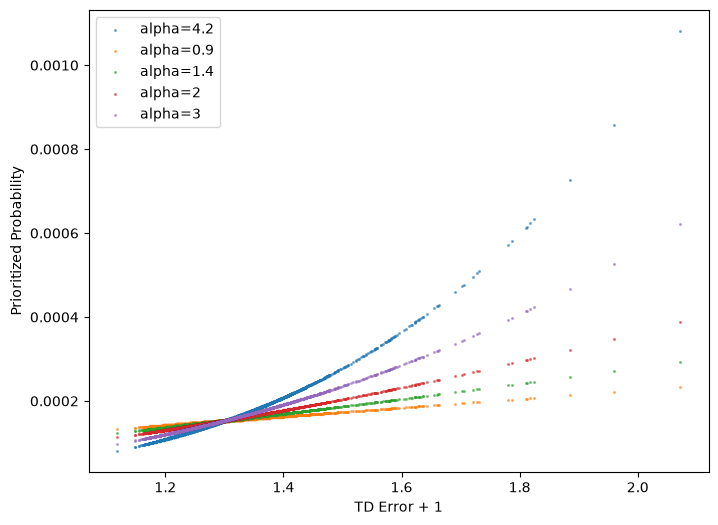

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(td_error_edited, (td_raised_4_2 / td_raised_4_2.sum()), alpha=0.5, s= 1.5, label='alpha=4.2')
plt.scatter(td_error_edited, (td_raised_0_9 / td_raised_0_9.sum()), alpha=0.5, s= 1.5, label='alpha=0.9')
plt.scatter(td_error_edited, (td_raised_1_4 / td_raised_1_4.sum()), alpha=0.5, s= 1.5, label='alpha=1.4')
plt.scatter(td_error_edited, (td_raised_2 / td_raised_2.sum()), alpha=0.5, s= 1.5, label='alpha=2')
plt.scatter(td_error_edited, (td_raised_3 / td_raised_3.sum()), alpha=0.5, s= 1.5, label='alpha=3')
plt.xlabel('TD Error + 1')
plt.ylabel('Prioritized Probability')
plt.legend()
plt.show()